Sel 1 — Mount Google Drive & Install Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn opencv-python lime tqdm -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Sel 2 — Import Library

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)

from lime import lime_image
from skimage.segmentation import mark_boundaries

Sel 3 — Konfigurasi Path & Parameter

In [ ]:
BASE_DIR   = Path("/content/drive/MyDrive/Pothole_Classification_Project")
TRAIN_DIR  = BASE_DIR / "dataset/2_processed/train"
TEST_DIR   = BASE_DIR / "dataset/2_processed/test"
MODEL_DIR  = BASE_DIR / "saved_models"
OUTPUT_DIR = BASE_DIR / "outputs"

CLASSES    = ["berlubang", "mulus"]
IMG_SIZE   = (32, 32)
FLAT_SIZE  = IMG_SIZE[0] * IMG_SIZE[1] * 3

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Konfigurasi siap.")
print(f"   Panjang vektor input : {FLAT_SIZE}")

✅ Konfigurasi siap.
   Panjang vektor input : 3072


Sel 5 — Fungsi Load & Flatten Gambar

In [ ]:
def load_and_flatten(img_path, size=IMG_SIZE):
    """
    Baca gambar RGB → resize 32x32 → normalisasi → flatten.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, size, interpolation=cv2.INTER_AREA)
    img_norm    = img_resized.astype(np.float32) / 255.0
    return img_norm.flatten()

Sel 6 — Load Train Set

In [ ]:
print("⚙️  Memuat Train Set...\n")

X_train, y_train = [], []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    for path in tqdm(paths, desc=f"[{cls}]"):
        feat = load_and_flatten(path)
        if feat is not None:
            X_train.append(feat)
            y_train.append(label_idx)

X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)

print(f"\n✅ Train set siap.")
print(f"   Jumlah sampel : {X_train.shape[0]}")
print(f"   Panjang vektor: {X_train.shape[1]}")

⚙️  Memuat Train Set...



[mulus]: 100%|██████████| 1540/1540 [00:20<00:00, 73.87it/s] 


✅ Train set siap.
   Jumlah sampel : 3080
   Panjang vektor: 3072


Sel 7 — Load Test Set

In [ ]:
print("⚙️  Memuat Test Set...\n")

X_test, y_test  = [], []
test_images_raw = []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TEST_DIR / cls).glob("*.jpg"))
    for path in tqdm(paths, desc=f"[{cls}]"):
        img = cv2.imread(str(path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_display = cv2.resize(img_rgb, (224, 224))
        test_images_raw.append(img_display)

        feat = load_and_flatten(path)
        if feat is not None:
            X_test.append(feat)
            y_test.append(label_idx)

X_test          = np.array(X_test, dtype=np.float32)
y_test          = np.array(y_test, dtype=np.float32)
test_images_raw = np.array(test_images_raw)

print(f"\n✅ Test set siap.")
print(f"   Jumlah sampel : {X_test.shape[0]}")

⚙️  Memuat Test Set...



[mulus]: 100%|██████████| 35/35 [00:01<00:00, 33.95it/s]


✅ Test set siap.
   Jumlah sampel : 70


Sel 7 — Normalisasi Fitur

In [ ]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Fitur dinormalisasi dengan StandardScaler.")

✅ Fitur dinormalisasi dengan StandardScaler.


Sel 8 — Implementasi PNN Manual

In [ ]:
class PNN:
    def __init__(self, std=0.1, batch_size=10):
        self.std        = std
        self.batch_size = batch_size
        self.X_train    = None
        self.y_train    = None
        self.classes_   = None

    def fit(self, X, y):
        self.X_train  = X
        self.y_train  = y
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        proba = np.zeros((len(X), len(self.classes_)))

        for batch_start in range(0, len(X), self.batch_size):
            batch_end = min(batch_start + self.batch_size, len(X))
            X_batch   = X[batch_start:batch_end]

            for i, cls in enumerate(self.classes_):
                X_cls   = self.X_train[self.y_train == cls]
                diff    = X_batch[:, np.newaxis, :] - X_cls[np.newaxis, :, :]
                dist_sq = np.sum(diff ** 2, axis=2)
                kernels = np.exp(-dist_sq / (2 * self.std ** 2))
                proba[batch_start:batch_end, i] = kernels.mean(axis=1)

        proba_sum = proba.sum(axis=1, keepdims=True)
        proba_sum = np.where(proba_sum == 0, 1, proba_sum)
        return proba / proba_sum

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

Sel 9 — Tuning Parameter std (Manual Grid Search)

In [ ]:
print("🔍 Mencari nilai std terbaik...\n")

std_values  = [0.01, 0.05, 0.1, 0.5, 1.0]
best_std    = None
best_acc    = 0
results_std = []

for std in std_values:
    pnn_temp    = PNN(std=std)
    pnn_temp.fit(X_train, y_train)
    y_pred_temp = pnn_temp.predict(X_test)
    acc_temp    = accuracy_score(y_test.astype(int), y_pred_temp.astype(int))
    results_std.append((std, acc_temp))
    print(f"   std={std:.3f} → Accuracy: {acc_temp:.4f} ({acc_temp*100:.2f}%)")

    if acc_temp > best_acc:
        best_acc = acc_temp
        best_std = std

print(f"\n✅ std terbaik : {best_std} → Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

#    std=0.010 → Accuracy: 0.5000 (50.00%)
#    std=0.050 → Accuracy: 0.5000 (50.00%)
#    std=0.100 → Accuracy: 0.5000 (50.00%)
#    std=0.500 → Accuracy: 0.5500 (55.00%)
#    std=1.000 → Accuracy: 0.8500 (85.00%)

# ✅ std terbaik : 1.0 → Accuracy: 0.8500 (85.00%)

pnn_model = PNN(std=best_std)
pnn_model.fit(X_train, y_train)

🔍 Mencari nilai std terbaik...

   std=0.010 → Accuracy: 0.5000 (50.00%)
   std=0.050 → Accuracy: 0.5000 (50.00%)
   std=0.100 → Accuracy: 0.5000 (50.00%)
   std=0.500 → Accuracy: 0.7000 (70.00%)
   std=1.000 → Accuracy: 0.8571 (85.71%)

✅ std terbaik : 1.0 → Accuracy: 0.8571 (85.71%)


Sel 10 — Training PNN (std Terbaik)

In [ ]:
# print("🏋️  Melatih PNN dengan std terbaik...\n")

# best_std  = 1.0

# pnn_model = PNN(std=best_std, batch_size=10)
# pnn_model.fit(X_train, y_train)

# print(f"✅ Training selesai! (std={best_std})")

Sel 11 — Plot Pengaruh std terhadap Akurasi

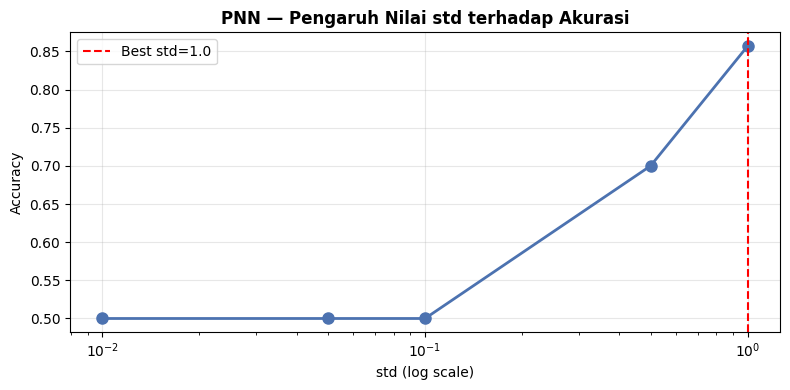

✅ Plot tuning std disimpan ke outputs/


In [ ]:
stds, accs = zip(*results_std)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(stds, accs, marker="o", color="#4C72B0", linewidth=2, markersize=8)
ax.axvline(x=best_std, color="red", linestyle="--", label=f"Best std={best_std}")
ax.set_xscale("log")
ax.set_title("PNN — Pengaruh Nilai std terhadap Akurasi", fontweight="bold")
ax.set_xlabel("std (log scale)")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pnn_std_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot tuning std disimpan ke outputs/")

Sel 12 — Evaluasi Model

In [ ]:
y_pred = pnn_model.predict(X_test).astype(int)
y_true = y_test.astype(int)

acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted")
rec  = recall_score   (y_true, y_pred, average="weighted")
f1   = f1_score       (y_true, y_pred, average="weighted")

print("=" * 45)
print("        HASIL EVALUASI — PNN")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASSES))

        HASIL EVALUASI — PNN
  Accuracy  : 0.8571  (85.71%)
  Precision : 0.8619
  Recall    : 0.8571
  F1-Score  : 0.8567

Classification Report:

              precision    recall  f1-score   support

   berlubang       0.82      0.91      0.86        35
       mulus       0.90      0.80      0.85        35

    accuracy                           0.86        70
   macro avg       0.86      0.86      0.86        70
weighted avg       0.86      0.86      0.86        70



Sel 13 — Confusion Matrix

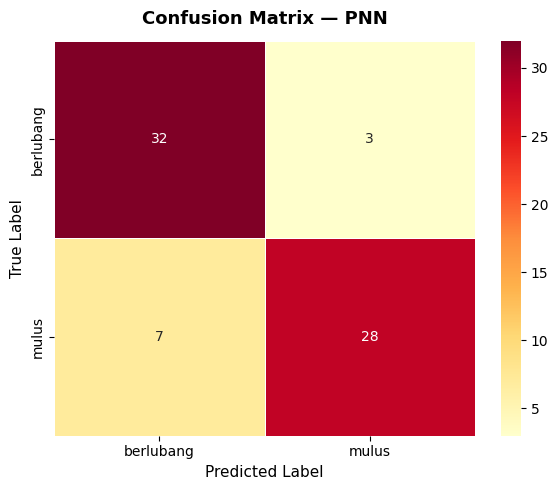

✅ Confusion matrix disimpan ke outputs/


In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — PNN", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cm_pnn.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix disimpan ke outputs/")

Sel 14 — Diagnosis Otomatis (tanpa CV)

In [ ]:
print("\n" + "=" * 50)
print("         DIAGNOSIS MODEL — PNN")
print("=" * 50)

# PNN tidak cocok untuk CV karena sangat lambat
# Diagnosis berdasarkan karakteristik arsitektur PNN
print(f"\n  Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Std           : {BEST_STD}")
print(f"  Jumlah neuron : {len(X_train)} (= seluruh data train)")

print("\n  📋 Kesimpulan:")

if acc < 0.7:
    print("  ⚠️  PERFORMA RENDAH — Kemungkinan nilai std tidak optimal.")
    print("      Saran: coba tuning std dengan nilai yang lebih kecil.")
elif acc >= 0.7 and acc < 0.85:
    print("  ✅ PERFORMA WAJAR untuk PNN dengan piksel mentah RGB.")
    print("     PNN tanpa ekstraksi fitur pada dataset kecil umumnya")
    print("     mencapai rentang 70-85%.")
elif acc >= 0.85:
    print("  ✅ PERFORMA BAIK — PNN berhasil mengestimasi densitas")
    print("     probabilistik dengan akurat pada dataset ini.")

print("\n  ℹ️  Catatan:")
print("  PNN tidak memiliki proses training iteratif sehingga")
print("  tidak rentan overfitting secara konvensional.")
print("  Seluruh data train disimpan sebagai memori neuron —")
print("  semakin besar dataset, semakin akurat estimasi densitasnya.")
print("=" * 50)


         DIAGNOSIS MODEL — PNN

  Test Accuracy  : 0.8571 (85.71%)
  Std           : 1.0
  Jumlah neuron : 3080 (= seluruh data train)

  📋 Kesimpulan:
  ✅ PERFORMA BAIK — PNN berhasil mengestimasi densitas
     probabilistik dengan akurat pada dataset ini.

  ℹ️  Catatan:
  PNN tidak memiliki proses training iteratif sehingga
  tidak rentan overfitting secara konvensional.
  Seluruh data train disimpan sebagai memori neuron —
  semakin besar dataset, semakin akurat estimasi densitasnya.


Sel 15 — Simpan Model

In [ ]:
joblib.dump(pnn_model, MODEL_DIR / "pnn_model.pkl")
joblib.dump(scaler,    MODEL_DIR / "scaler_pnn.pkl")

print("✅ Model tersimpan:")
print(f"   → {MODEL_DIR / 'pnn_model.pkl'}")
print(f"   → {MODEL_DIR / 'scaler_pnn.pkl'}")

✅ Model tersimpan:
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/pnn_model.pkl
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/scaler_pnn.pkl
